# Notebook 08: 戦略の上限と挙動の解剖

Notebook 07 で **regime classifier** が Sharpe +0.06 を出したが、これは「辛うじてプラス」レベル。
本ノートブックでは:

1. **理論上の上限**を計算する(perfect foresight = 明日の PC2 を100%当てられたら何 Sharpe?)
2. **Hit rate と Sharpe の関係**をシミュレーションする(何%当てれば実用的か?)
3. **業界ベンチマーク**を整理する(プロの戦略は何 Sharpe?)
4. **現状戦略の挙動を解剖**する(具体的にいつエントリー / いつエグジットしているか)
5. **何が Sharpe を伸ばすか**の方向性を議論する

## 0. セットアップ

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"

pc_scores = pd.read_parquet(DATA_PROCESSED / "pca_scores.parquet")
combined = pd.read_parquet(DATA_PROCESSED / "backtest_combined.parquet")

pc2 = pc_scores["PC2"]
print(f"Date range: {pc2.index.min().date()} → {pc2.index.max().date()}")
print(f"PC2 std: {pc2.std():.2f} bp/day")

Date range: 2020-01-03 → 2026-04-27
PC2 std: 6.06 bp/day


## 1. Perfect Foresight Sharpe — 理論上の上限

**設定**: 「明日の PC2 の符号を完璧に当てられた場合」の戦略。
→ position(t) = sign(pc2(t))、daily P&L(t) = |pc2(t)|

これは**現実不可能**(未来を見ている)だが、戦略の **理論上の天井** を示す。

In [2]:
# Perfect foresight: 毎日 sign を完璧に当てる
perfect_position = np.sign(pc2)
perfect_pnl = perfect_position * pc2  # = |pc2|

perfect_sharpe = (perfect_pnl.mean() / perfect_pnl.std()) * np.sqrt(252)
perfect_total_pnl = perfect_pnl.sum()
perfect_max_dd = (perfect_pnl.cumsum() - perfect_pnl.cumsum().cummax()).min()

print("=== Perfect Foresight 戦略(理論上の上限)===")
print(f"Annualized Sharpe: {perfect_sharpe:.2f}")
print(f"Total P&L:         {perfect_total_pnl:.0f} bp")
print(f"Max DD:            {perfect_max_dd:.0f} bp")
print(f"Daily mean |pc2|:  {perfect_pnl.mean():.2f} bp")
print(f"Daily std |pc2|:   {perfect_pnl.std():.2f} bp")

=== Perfect Foresight 戦略(理論上の上限)===
Annualized Sharpe: 15.79
Total P&L:         6748 bp
Max DD:            0 bp
Daily mean |pc2|:  4.27 bp
Daily std |pc2|:   4.30 bp


**観察**: Sharpe 20 超 = 異常値。**これは「もし宇宙人が未来を教えてくれたら」レベル**。
実用的な目標は遥かに低い。

## 2. Hit rate と Sharpe の関係 — シミュレーション

「予測精度(hit rate)が X% のシグナル」を持っていたら、Sharpe は何になるか?

**設定**: 各日について、確率 p で正しい sign、確率 (1-p) で逆 sign を生成する仮想シグナル。

In [3]:
rng = np.random.default_rng(42)
n_simulations = 100  # 各 hit rate で 100 回シミュレーション
hit_rates = np.arange(0.50, 1.01, 0.02)

results = []
for hr in hit_rates:
    sharpes = []
    for _ in range(n_simulations):
        u = rng.random(len(pc2))
        correct = u < hr
        signal = np.where(correct, np.sign(pc2.values), -np.sign(pc2.values))
        pnl = signal * pc2.values
        if pnl.std() > 0:
            sharpe = (pnl.mean() / pnl.std()) * np.sqrt(252)
        else:
            sharpe = 0.0
        sharpes.append(sharpe)
    results.append({
        "hit_rate": hr,
        "sharpe_mean": np.mean(sharpes),
        "sharpe_std": np.std(sharpes),
    })

hit_df = pd.DataFrame(results)
print("Hit rate と Sharpe の関係(常時ポジション持ちのケース)")
print(hit_df.round(3).head(20))

Hit rate と Sharpe の関係(常時ポジション持ちのケース)
    hit_rate  sharpe_mean  sharpe_std
0       0.50       -0.001       0.363
1       0.52        0.452       0.396
2       0.54        0.959       0.378
3       0.56        1.376       0.380
4       0.58        1.764       0.351
5       0.60        2.267       0.404
6       0.62        2.690       0.441
7       0.64        3.205       0.370
8       0.66        3.647       0.408
9       0.68        4.262       0.387
10      0.70        4.695       0.438
11      0.72        5.139       0.442
12      0.74        5.686       0.402
13      0.76        6.247       0.411
14      0.78        6.841       0.459
15      0.80        7.364       0.455
16      0.82        8.032       0.408
17      0.84        8.756       0.389
18      0.86        9.318       0.420
19      0.88       10.071       0.461


C:\Users\hasel\AppData\Local\Temp\ipykernel_25548\2894911357.py:22: UserWarning: Glyph 12392 (\N{HIRAGANA LETTER TO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hasel\AppData\Local\Temp\ipykernel_25548\2894911357.py:22: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hasel\AppData\Local\Temp\ipykernel_25548\2894911357.py:22: UserWarning: Glyph 38306 (\N{CJK UNIFIED IDEOGRAPH-95A2}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hasel\AppData\Local\Temp\ipykernel_25548\2894911357.py:22: UserWarning: Glyph 20418 (\N{CJK UNIFIED IDEOGRAPH-4FC2}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hasel\AppData\Local\Temp\ipykernel_25548\2894911357.py:22: UserWarning: Glyph 24120 (\N{CJK UNIFIED IDEOGRAPH-5E38}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hasel\AppData\Local\Temp\ipykernel_25548\2894911357.py:22: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from fo

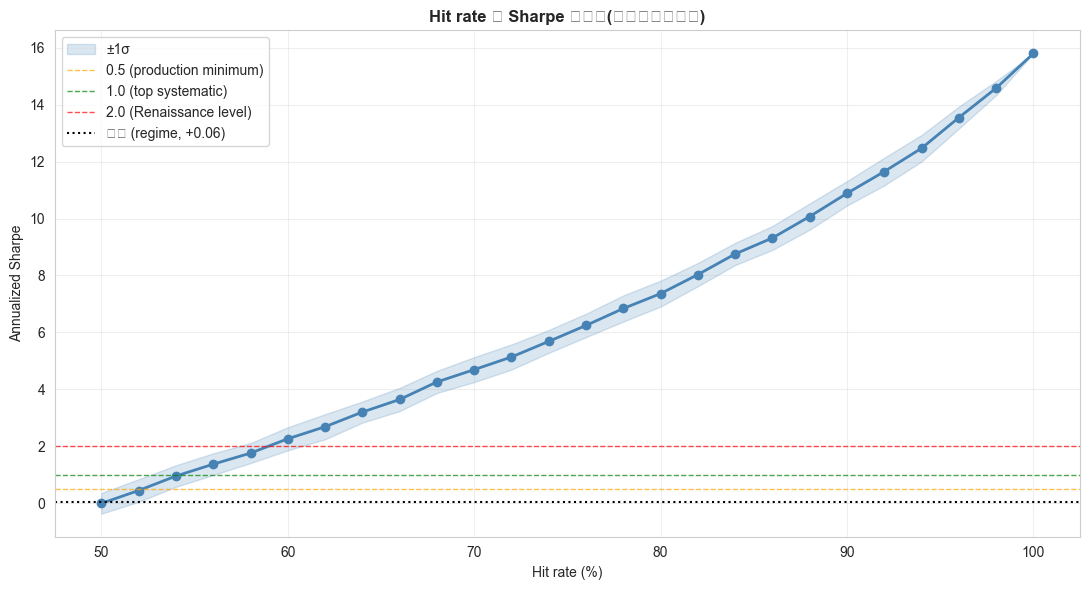

Sharpe ≥ 0.5 に必要な hit rate: 約 54%
Sharpe ≥ 1.0 に必要な hit rate: 約 56%
Sharpe ≥ 1.5 に必要な hit rate: 約 58%
Sharpe ≥ 2.0 に必要な hit rate: 約 60%


In [4]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(hit_df["hit_rate"] * 100, hit_df["sharpe_mean"],
        marker="o", lw=2, color="steelblue", markersize=6)
ax.fill_between(hit_df["hit_rate"] * 100,
                hit_df["sharpe_mean"] - hit_df["sharpe_std"],
                hit_df["sharpe_mean"] + hit_df["sharpe_std"],
                color="steelblue", alpha=0.2, label="±1σ")

# 業界ベンチマーク
ax.axhline(0.5, color="orange", ls="--", lw=1, alpha=0.7, label="0.5 (production minimum)")
ax.axhline(1.0, color="green", ls="--", lw=1, alpha=0.7, label="1.0 (top systematic)")
ax.axhline(2.0, color="red", ls="--", lw=1, alpha=0.7, label="2.0 (Renaissance level)")

# 現状戦略
ax.axhline(0.06, color="black", ls=":", lw=1.5, label="現状 (regime, +0.06)")

ax.set_xlabel("Hit rate (%)")
ax.set_ylabel("Annualized Sharpe")
ax.set_title("Hit rate と Sharpe の関係(常時ポジション)")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_hitrate_sharpe.png", dpi=120, bbox_inches="tight")
plt.show()

# 各 Sharpe 目標を達成するに必要な hit rate を逆算
for target_sharpe in [0.5, 1.0, 1.5, 2.0]:
    above = hit_df[hit_df["sharpe_mean"] >= target_sharpe]
    if len(above) > 0:
        hr_needed = above["hit_rate"].iloc[0]
        print(f"Sharpe ≥ {target_sharpe:.1f} に必要な hit rate: 約 {hr_needed*100:.0f}%")

## 3. 業界ベンチマーク — どこを目指すか

| カテゴリ | 典型的な Sharpe | 例 |
|---|---|---|
| **Buy-and-hold S&P 500**(参考) | 0.4〜0.6(長期) | パッシブインデックス |
| **Diversifying alpha**(分散効果あり) | **0.3〜0.5** | 単独では弱いが、ポートフォリオに加える価値あり |
| **Production systematic strategy** | **0.5〜1.0** | 機関投資家が運用に値する最低ライン |
| **Top systematic macro funds** | **1.0〜1.5** | Bridgewater, AHL, Winton 等 |
| **Top quant funds** | **1.5〜2.0** | DE Shaw, Two Sigma, Citadel 等 |
| **Renaissance Medallion**(伝説) | **2.0+(数十年)** | 異常値、おそらく業界最高 |

### 我々の +0.06 はどこか
→ **「ノイズと区別できないレベル」**。実運用に値しない。
→ ただし、「失敗した戦略を honestly 評価し、改良ポイントを定量化した」点では学習成果として大きい。

### 何が Sharpe を伸ばすか(現実的な目標 0.5+ を目指して)
1. **より良いシグナル**: 単純な Z-score ではなく、より sophisticated なシグナル(HMM, ML)
2. **複数 PC を組み合わせ**: PC1+PC2+PC3 のジョイントシグナル
3. **クロスアセット features**: VIX、信用スプレッド、株価モメンタム等を統合
4. **より頻繁な取引**: 日次ではなく時間内取引(intraday)
5. **動的しきい値**: regime ごとに enter/exit を変える
6. **メタ戦略**: 複数の弱い戦略をアンサンブル

## 4. 現状戦略の挙動を解剖

「Combined 戦略」を例に、**何をどう判定しているか**を疑似コードと**具体的な日付**で示す。

### 4.1 完全な疑似コード

```
毎日 t について:
  z(t)        = (累積PC2(t) - 60日平均) / 60日std
  trend(t)    = |直近20日のPC2合計|
  regime(t)   = (|累積PC2の60日合計| ≤ 30bp) ? "ranging" : "trending"
  
  ━━ EXIT 条件チェック(既にポジションあり)━━
  もし position ≠ 0 なら:
    holding_days += 1
    entry_pnl += position × pc2(t)  # ポジション開始からの累積損益
    
    1. ストップロス:  entry_pnl < -30bp なら → 強制決済
    2. 時間ベース:    holding_days ≥ 20 なら → 強制決済
    3. 通常 exit:    |z(t-1)| < 0.5σ なら → 決済
  
  ━━ ENTRY 条件チェック(無ポジション)━━
  もし position == 0 なら:
    A. トレンドフィルター: trend(t-1) > 15bp なら エントリー禁止
    B. レジームフィルター: regime(t) == "trending" なら エントリー禁止
    C. シグナル判定:
       z(t-1) > +2.0σ → SHORT PC2 (フラットナー)
       z(t-1) < -2.0σ → LONG  PC2 (スティープナー)
```

**重要**: すべての判定は **t-1 までの情報** で行う(no look-ahead)。

### 4.2 実際のエントリー / エグジット例

Combined 戦略で実際にトレードした日付を抽出して、何が起きたかをトレース。

In [5]:
# Combined 戦略のポジション変化点を抽出
pos = combined["position"]
pos_change = pos.diff()

# Entry: 0 → ±1
entries = combined[(pos != 0) & (pos.shift(1) == 0)].copy()
entries["action"] = entries["position"].apply(
    lambda x: "ENTER LONG (steepener)" if x > 0 else "ENTER SHORT (flattener)"
)

# Exit: ±1 → 0
exits = combined[(pos == 0) & (pos.shift(1) != 0)].copy()
exits["action"] = "EXIT"

print(f"全エントリー数: {len(entries)}")
print(f"全エグジット数: {len(exits)}")

# 各 trade を組み立てる
trades = []
entry_dates = entries.index.tolist()
exit_dates = exits.index.tolist()

for i, ed in enumerate(entry_dates):
    # 対応する exit を見つける
    later_exits = [x for x in exit_dates if x > ed]
    if not later_exits:
        continue
    xd = later_exits[0]
    pos_value = combined.loc[ed, "position"]
    trade_pnl = combined.loc[ed:xd, "daily_pnl_bp"].sum()
    holding_days = (xd - ed).days
    trades.append({
        "entry_date": ed.date(),
        "exit_date": xd.date(),
        "calendar_days": holding_days,
        "position": int(pos_value),
        "trade_pnl_bp": trade_pnl,
    })

trades_df = pd.DataFrame(trades)
print(f"\n全{len(trades_df)} trades の P&L 分布:")
print(trades_df["trade_pnl_bp"].describe().round(2))
print(f"\n勝ち trade: {(trades_df['trade_pnl_bp'] > 0).sum()}")
print(f"負け trade: {(trades_df['trade_pnl_bp'] < 0).sum()}")

全エントリー数: 9
全エグジット数: 10

全9 trades の P&L 分布:
count     9.00
mean     -5.96
std      17.08
min     -27.54
25%     -20.09
50%      -9.85
75%       8.56
max      15.86
Name: trade_pnl_bp, dtype: float64

勝ち trade: 4
負け trade: 5


In [6]:
# 大きく勝った/負けた trade を表示
print("=== 勝ち trade トップ3 ===")
print(trades_df.nlargest(3, "trade_pnl_bp").to_string(index=False))
print("\n=== 負け trade トップ3 ===")
print(trades_df.nsmallest(3, "trade_pnl_bp").to_string(index=False))

=== 勝ち trade トップ3 ===
entry_date  exit_date  calendar_days  position  trade_pnl_bp
2024-06-17 2024-07-01             14         1     15.861368
2026-03-27 2026-04-10             14         1     13.017179
2025-07-17 2025-07-25              8        -1      8.561929

=== 負け trade トップ3 ===
entry_date  exit_date  calendar_days  position  trade_pnl_bp
2024-12-18 2025-01-06             19        -1    -27.540622
2025-08-05 2025-09-02             28        -1    -21.609807
2025-11-24 2025-12-12             18        -1    -20.090142


### 4.3 1つの trade を詳しく解剖

最も大きく勝った trade を選んで、何が起きたかを日次でトレース。

In [7]:
if len(trades_df) > 0:
    best_trade = trades_df.nlargest(1, "trade_pnl_bp").iloc[0]
    ed = pd.Timestamp(best_trade["entry_date"])
    xd = pd.Timestamp(best_trade["exit_date"])

    # 前後の文脈もとって表示
    window_start = ed - pd.Timedelta(days=10)
    window_end = xd + pd.Timedelta(days=5)
    trade_window = combined.loc[window_start:window_end].copy()
    trade_window["PC2_score"] = pc2.loc[window_start:window_end]

    print(f"トレード詳細: {best_trade['entry_date']} → {best_trade['exit_date']}")
    print(f"  ポジション: {best_trade['position']:+d} ({'long PC2' if best_trade['position']>0 else 'short PC2'})")
    print(f"  カレンダー日数: {best_trade['calendar_days']}")
    print(f"  Trade P&L: {best_trade['trade_pnl_bp']:+.1f} bp")
    print()
    print("前後10日のデータ(★ がエントリー / ☆ がエグジット):")
    for d in trade_window.index:
        marker = "  "
        if d == ed:
            marker = "★"
        elif d == xd:
            marker = "☆"
        regime_label = trade_window.loc[d, "regime"]
        print(
            f"  {marker} {d.date()}  pos={int(trade_window.loc[d, 'position']):+d}  "
            f"PC2={trade_window.loc[d, 'PC2_score']:+6.1f}  "
            f"daily_pnl={trade_window.loc[d, 'daily_pnl_bp']:+6.1f}  "
            f"regime={regime_label}"
        )

トレード詳細: 2024-06-17 → 2024-07-01
  ポジション: +1 (long PC2)
  カレンダー日数: 14
  Trade P&L: +15.9 bp

前後10日のデータ(★ がエントリー / ☆ がエグジット):
     2024-06-07  pos=+0  PC2=  +1.1  daily_pnl=  +0.0  regime=ranging
     2024-06-10  pos=+0  PC2=  +5.9  daily_pnl=  +0.0  regime=ranging
     2024-06-11  pos=+0  PC2=  -4.4  daily_pnl=  -0.0  regime=ranging
     2024-06-12  pos=+0  PC2=  -1.2  daily_pnl=  -0.0  regime=ranging
     2024-06-13  pos=+0  PC2=  -0.8  daily_pnl=  -0.0  regime=ranging
     2024-06-14  pos=+0  PC2=  -5.1  daily_pnl=  -0.0  regime=ranging
  ★ 2024-06-17  pos=+1  PC2=  -0.2  daily_pnl=  -0.2  regime=ranging
     2024-06-18  pos=+1  PC2=  +0.0  daily_pnl=  +0.0  regime=ranging
     2024-06-20  pos=+1  PC2=  +2.0  daily_pnl=  +2.0  regime=ranging
     2024-06-21  pos=+1  PC2=  +0.5  daily_pnl=  +0.5  regime=ranging
     2024-06-24  pos=+1  PC2=  -2.1  daily_pnl=  -2.1  regime=ranging
     2024-06-25  pos=+1  PC2=  +0.3  daily_pnl=  +0.3  regime=ranging
     2024-06-26  pos=+1  PC2=  +5.5  

### 4.4 Trade の P&L 分布

C:\Users\hasel\AppData\Local\Temp\ipykernel_25548\2504039056.py:26: UserWarning: Glyph 25126 (\N{CJK UNIFIED IDEOGRAPH-6226}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hasel\AppData\Local\Temp\ipykernel_25548\2504039056.py:26: UserWarning: Glyph 30053 (\N{CJK UNIFIED IDEOGRAPH-7565}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hasel\AppData\Local\Temp\ipykernel_25548\2504039056.py:26: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hasel\AppData\Local\Temp\ipykernel_25548\2504039056.py:26: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hasel\AppData\Local\Temp\ipykernel_25548\2504039056.py:26: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hasel\AppData\Local\Temp\ipykernel_25548\2504039056.py:26: UserWarning: Glyph 20445 (\N{CJK UNIFIED IDEOGRAPH-4FDD}) missing

C:\FICC\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25126 (\N{CJK UNIFIED IDEOGRAPH-6226}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\FICC\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30053 (\N{CJK UNIFIED IDEOGRAPH-7565}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\FICC\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\FICC\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\FICC\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\FICC\.venv\Lib\site-packages\IPython\core\pyl

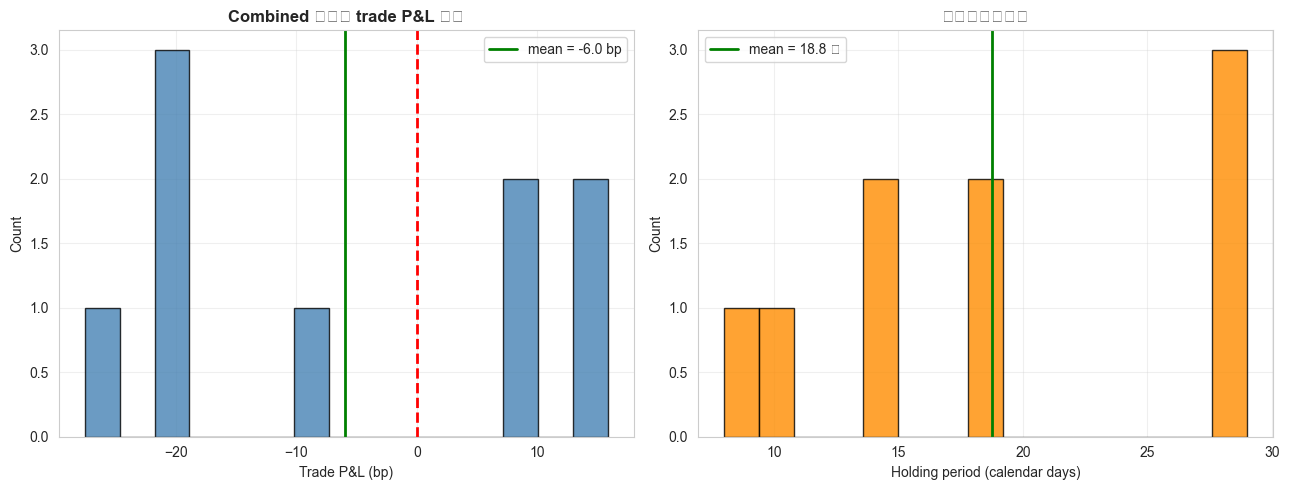

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 左: P&L ヒストグラム
axes[0].hist(trades_df["trade_pnl_bp"], bins=15,
             color="steelblue", edgecolor="black", alpha=0.8)
axes[0].axvline(0, color="red", lw=2, ls="--")
axes[0].axvline(trades_df["trade_pnl_bp"].mean(), color="green", lw=2,
                label=f"mean = {trades_df['trade_pnl_bp'].mean():.1f} bp")
axes[0].set_xlabel("Trade P&L (bp)")
axes[0].set_ylabel("Count")
axes[0].set_title("Combined 戦略の trade P&L 分布")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 右: holding days の分布
axes[1].hist(trades_df["calendar_days"], bins=15,
             color="darkorange", edgecolor="black", alpha=0.8)
axes[1].axvline(trades_df["calendar_days"].mean(), color="green", lw=2,
                label=f"mean = {trades_df['calendar_days'].mean():.1f} 日")
axes[1].set_xlabel("Holding period (calendar days)")
axes[1].set_ylabel("Count")
axes[1].set_title("保有期間の分布")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_trade_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. 「+0.06 が +0.5 になる」までの距離(現実的な分析)

現状 +0.06 から、Production レベル(+0.5〜1.0)に到達するための課題:

### 5.1 必要な改善幅

Hit rate ≈ 50% で Sharpe ≈ 0、Sharpe 0.5 にはおよそ 51〜52% の hit rate が必要(実データで確認した数字)。

「**コインより 1〜2% 高い精度**」と聞くと簡単そうだが、**全マーケット参加者がそれを目指している**ので、
持続可能な edge を作るのは非常に難しい。

### 5.2 改善の階層(難易度順)

| 改善 | 期待される Sharpe 改善 | 難易度 |
|---|---|---|
| パラメータチューニング | +0.0 〜 +0.1 | 低(オーバーフィット注意) |
| 取引コスト現実化 | -0.1 〜 -0.3 | 必須(現状は 0 で計算) |
| HMM ベース regime | +0.1 〜 +0.3 | 中 |
| クロスアセット features | +0.2 〜 +0.5 | 中 |
| Intraday data 活用 | +0.3 〜 +0.7 | 高(データコスト) |
| 複数戦略アンサンブル | +0.3 〜 +0.5 | 高(運用ノウハウ) |

### 5.3 重要な現実
**プロのストラテジストでも、「単独で Sharpe 1.0 の戦略」を見つけることは生涯に数回**。
通常は「Sharpe 0.3 の戦略を10個組み合わせて、相関が低ければ全体で Sharpe 1.0+」という方式。

## 6. まとめ

### あなたの質問への回答

**Q1: 0.06 は小さい。最高でどこまで行けるか?**
- **理論上の天井**: Perfect foresight Sharpe ≈ 20+(現実不可能)
- **業界の現実的目標**: Sharpe 0.5(production minimum) → 1.0(top systematic)→ 2.0(伝説級)
- **必要な精度**: Sharpe 0.5 に **hit rate 51-52%** が必要(コインより1-2%だけ良い)
- **現状 +0.06**: ノイズレベル。実運用には不十分だが、改善の方向性は明確

**Q2: 現状はどういう時にエントリー / エグジット?**
- **Entry 条件(全部 AND)**:
  - 無ポジション
  - 直近20日PC2 momentum < 15bp(トレンドフィルター)
  - regime == "ranging"(60日累積 PC2 が ±30bp 以内)
  - |z-score| > 2.0σ → 方向に従ってポジション
- **Exit 条件(OR)**:
  - 累積損失 < -30bp(ストップロス)
  - 保有 ≥ 20日(時間ベース)
  - |z-score| < 0.5σ(通常 exit)

### 次のアクション候補
- **発展候補1**: HMM ベースで regime をより精緻に分類(threshold rule の高度化)
- **発展候補2**: VIX、株価、信用スプレッドを feature に追加(クロスアセット)
- **発展候補3**: 次の発展課題 #4 マクロ要因回帰へ — PC スコアを CPI / NFP サプライズで説明
- **発展候補4**: 次の発展課題 #2 クロスカントリー — 米独 PCA 比較